# 01. Data Generation (Mock Data) & Assumptions

Notebook ชุดนี้จัดทำขึ้นเพื่อจำลองข้อมูล (Mock Data) สำหรับนำไปใช้ในระบบจัดกลุ่มลูกค้า (Customer Segmentation)
เนื่องจากโจทย์อนุญาตให้สร้างข้อมูลจำลองเพื่อเป็น Starting Point ในการวาง Data Plan ได้
โดยมีรายละเอียดและข้อสมมติฐานของข้อมูลดังนี้:

### รายละเอียดการจำลองข้อมูล
* **ตารางที่ 1: Customer Master** จำลองข้อมูลลูกค้ารวมจำนวน 50 คน
* **ตารางที่ 2: Sales Transaction** จำลองประวัติการซื้อขาย (Transactions) จำนวน 500 รายการ ย้อนหลัง 90 วัน

### Assumptions & Limitations (ข้อสมมติฐานและข้อจำกัด)
1. **Assumption:** สมมติว่าข้อมูลชุดนี้ถูกดึงมาจากระบบ POS (Point of Sale) ของร้านค้าปลีกย้อนหลัง 3 เดือน
และลูกค้าทุกคนมีการสแกนรหัสสมาชิก (`customer_id`) ทุกครั้งที่มีการซื้อขาย
2. **Limitation:** ข้อมูลจำลองชุดนี้ยังขาดมิติของประเภทสินค้า (Product Category) และต้นทุนสินค้า (Cost)
ทำให้การวิเคราะห์จัดกลุ่มในโปรเจกต์นี้จะมุ่งเน้นไปที่พฤติกรรมการใช้จ่ายในภาพรวม (RFM Analysis) เป็นหลัก

In [14]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# ตั้งค่า Seed เพื่อให้สุ่มออกมารูปแบบเดิมทุกครั้งที่รัน
np.random.seed(42)

# 1. สร้างตาราง Customer Master (ลูกค้ารวม 50 คน)
customer_ids = [f"C{str(i).zfill(3)}" for i in range(1, 51)]
df_customer = pd.DataFrame({
    'customer_id': customer_ids,
    'customer_taxonomies': 'Unassigned' # รอเติมกลุ่มลูกค้าหลังทำ Clustering
})

# 2. สร้างตาราง Sales Transaction (ข้อมูลการขาย 500 transaction ย้อนหลัง 90 วัน)
n_transactions = 500
end_date = datetime.now()
start_date = end_date - timedelta(days=90)

# สุ่มวันที่ขาย ย้อนหลังไปใน 90 วัน พร้อมสุ่มเวลาเป็นชั่วโมงและนาที
random_dates = [start_date + timedelta(
    days=int(np.random.randint(0, 90)),
    hours=int(np.random.randint(0, 24)),      # สุ่มชั่วโมง 0-23
    minutes=int(np.random.randint(0, 60))     # สุ่มนาที 0-59
) for _ in range(n_transactions)]

df_sales = pd.DataFrame({
    'datetime': random_dates,
    'customer_id': np.random.choice(customer_ids, n_transactions),
    'product_id': [f"P{str(np.random.randint(1, 20)).zfill(3)}" for _ in range(n_transactions)],
    'price': np.random.uniform(50, 1500, n_transactions).round(2),
    'qty': np.random.randint(1, 10, n_transactions)
})

# เพิ่มคอลัมน์ total_amount (ราคา x จำนวน)
df_sales['total_amount'] = df_sales['price'] * df_sales['qty']

# บันทึกข้อมูลเป็นไฟล์ CSV
df_customer.to_csv('customer_master.csv', index=False)
df_sales.to_csv('sales_transaction.csv', index=False)

print("--- Customer Master ---")
display(df_customer.head())

print("\n--- Sales Transaction ---")
display(df_sales.head())
print("\n✅ บันทึกไฟล์ CSV สำเร็จ! พร้อมนำไปใช้งานต่อ")

--- Customer Master ---


,customer_id,customer_taxonomies
0,C001,Unassigned
1,C002,Unassigned
2,C003,Unassigned
3,C004,Unassigned
4,C005,Unassigned



--- Sales Transaction ---


,datetime,customer_id,product_id,price,qty,total_amount
0,2026-05-07 18:26:32.764591,C035,P001,551.84,6,3311.04
1,2026-05-28 00:22:32.764591,C034,P002,1464.63,5,7323.15
2,2026-06-08 01:54:32.764591,C047,P001,979.41,3,2938.23
3,2026-05-31 03:36:32.764591,C024,P001,1242.60,9,11183.40
4,2026-04-09 06:05:32.764591,C022,P009,242.16,5,1210.80



✅ บันทึกไฟล์ CSV สำเร็จ! พร้อมนำไปใช้งานต่อ


### ⚠️ Assumptions & Limitations

| ข้อมูล | Assumption |
|--------|------------|
| `price` ใน Sales Transaction | คือ final selling price ณ วันที่ขาย ซึ่งอาจผันแปรได้ตาม dynamic pricing หรือ promotion ที่ใช้ในแต่ละ transaction จึงต่างกันได้แม้ product_id เดียวกัน |
| `customer_taxonomies` = Unassigned | เป็น placeholder รอ populate หลังจากรัน K-Means Segmentation — ผลลัพธ์จากโมเดลจะถูกนำมาอัปเดต column นี้ในขั้นตอนถัดไป |
| ช่วงเวลาข้อมูล | สมมติว่าข้อมูลชุดนี้มาจากยอดขายย้อนหลัง 90 วัน (1 Quarter) |
| จำนวน transaction | Mock ไว้ 500 rows เพื่อให้มีข้อมูลเพียงพอสำหรับการทำ RFM Analysis และ Clustering |

1. ข้อมูลนั้นใช้ทำอะไร:  นำข้อมูล datetime, customer_id, qty, และ price จาก Sales Transaction มาคำนวณหาค่า RFM (Recency, Frequency, Monetary) ของลูกค้าแต่ละราย  

2. ช่วยแก้ปัญหาอะไร:  ช่วยให้มองเห็นพฤติกรรมการซื้อที่ซ่อนอยู่ (เช่น ใครซื้อบ่อยแต่ยอดน้อย ใครยอดเยอะแต่หายไปนาน) เพื่อนำไปจัดกลุ่มลูกค้าได้แม่นยำกว่าการใช้ความรู้สึก  

3. มีผลต่อ model หรือ business อย่างไร:  ข้อมูลชุดนี้จะเป็น Input สำคัญให้โมเดล (เช่น K-Means) จัดกลุ่มลูกค้า (Customer Segments) ซึ่งธุรกิจสามารถใช้ผลลัพธ์นี้ไปออกแบบโปรโมชั่น (Cross-sell/Up-sell) ได้ตรงกลุ่มเป้าหมาย เพื่อเพิ่มยอดขายต่อบิล (Basket Size)  

4. มี assumption หรือ limitation อะไร:   
- Assumption: สมมติให้ข้อมูลชุดนี้ดึงมาจากระบบ POS ของร้านค้าย้อนหลัง 90 วัน และลูกค้าทุกคนมีรหัสสมาชิก (customer_id) ทุกครั้งที่ซื้อ
- Limitation: ข้อมูล Mockup นี้ยังขาดมิติเรื่องต้นทุน (Cost) และข้อมูลสินค้า (Product Category) ทำให้การจัดกลุ่มยังเน้นไปที่พฤติกรรมการจ่ายเงินเป็นหลัก ยังไม่ได้เจาะลึกความชอบรายสินค้า

# 02. RFM Calculation & K-Means Clustering

ในขั้นตอนนี้จะทำการแปลงข้อมูลจากประวัติการซื้อ (Sales Transaction) ให้กลายเป็นพฤติกรรมรายบุคคลผ่านเทคนิค RFM Analysis จากนั้นจะนำข้อมูลที่ได้ไปทำการรักษาระดับสเกล (Scaling) และใช้โมเดล Machine Learning อย่าง **K-Means Clustering** ในการจัดกลุ่มลูกค้าออกเป็น 3 กลุ่มหลัก เพื่อนำผลลัพธ์ไปอัปเดตในตาราง Customer Master ต่อไป

/tmp/ipykernel_4837/1167330011.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_customer, x='customer_taxonomies',


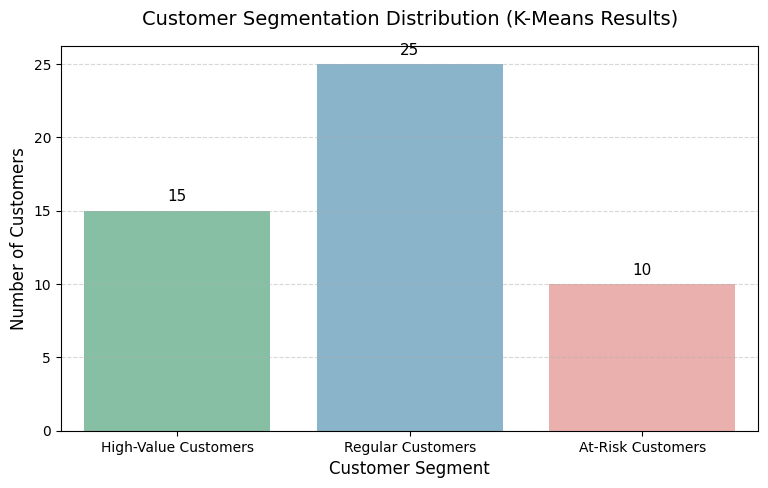


--- ผลลัพธ์การคำนวณค่าเฉลี่ยแต่ละกลุ่มเพื่อตรวจสอบโมเดล ---


,Recency,Frequency,Monetary
Segment,,,
At-Risk Customers,23.70,7.70,25298.00
High-Value Customers,8.13,13.73,55176.48
Regular Customers,5.52,8.68,33716.74



✅ อัปเดตกลุ่มลูกค้าลงใน customer_master.csv และพล็อตกราฟเรียบร้อย!


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. คำนวณค่า RFM ยืนพื้นจากวันล่าสุดในข้อมูล + 1 วัน
snapshot_date = df_sales['datetime'].max() + timedelta(days=1)

df_rfm = df_sales.groupby('customer_id').agg({
    'datetime': lambda x: (snapshot_date - x.max()).days,  # Recency (จำนวนวันที่ไม่ได้มาซื้อ)
    'customer_id': 'count',                                # Frequency (จำนวนครั้งที่มาซื้อ)
    'total_amount': 'sum'                                  # Monetary (ยอดเงินรวมที่จ่าย)
}).rename(columns={
    'datetime': 'Recency',
    'customer_id': 'Frequency',
    'total_amount': 'Monetary'
}).reset_index()

# 2. ทำ Data Scaling เพื่อปรับระดับตัวเลขให้อยู่ในสเกลเดียวกันก่อนเข้าโมเดล
features = ['Recency', 'Frequency', 'Monetary']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_rfm[features])

# 3. รันโมเดล K-Means Clustering แบ่งกลุ่มลูกค้าออกเป็น 3 กลุ่ม
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_rfm['Cluster'] = kmeans.fit_predict(X_scaled)

# 4. กำหนดชื่อกลุ่มลูกค้าให้เข้าใจง่ายตามหลักธุรกิจ (วัดจากยอดจ่ายเฉลี่ย Monetary)
monetary_means = df_rfm.groupby('Cluster')['Monetary'].mean().sort_values(ascending=False)
segment_mapping = {
    monetary_means.index[0]: 'High-Value Customers',  # กลุ่มเปย์หนัก ยอดซื้อสูง
    monetary_means.index[1]: 'Regular Customers',     # กลุ่มลูกค้าทั่วไป ซื้อเรื่อยๆ
    monetary_means.index[2]: 'At-Risk Customers'      # กลุ่มเงียบหาย นานๆ มาที
}
df_rfm['Segment'] = df_rfm['Cluster'].map(segment_mapping)

# 5. อัปเดตข้อมูลกลุ่มลูกค้ากลับเข้าไปที่ตาราง Customer Master (แทนที่ Unassignedเดิม)
df_customer = df_customer.drop(columns=['customer_taxonomies']).merge(
    df_rfm[['customer_id', 'Segment']], on='customer_id', how='left'
).rename(columns={'Segment': 'customer_taxonomies'})

# บันทึกไฟล์เวอร์ชันอัปเดตทับไฟล์เดิม
df_customer.to_csv('customer_master.csv', index=False)

# 6. พล็อตกราฟแสดงผลลัพธ์ (Simple EDA ของกลุ่มลูกค้า) ด้วยโทนสีพาสเทล
# โดยเราจะใช้สีเขียวมิ้นต์ (#BDFCC9), สีฟ้าพาสเทล (#BDE0FE), และสีชมพูพาสเทล (#FFC8DD) สื่อความหมาย

plt.figure(figsize=(9, 5))
pastel_colors = ["#7EC8A4", "#7EB8D4", "#F4A7A3"]
ax = sns.countplot(data=df_customer, x='customer_taxonomies',
                  order=['High-Value Customers', 'Regular Customers', 'At-Risk Customers'],
                  palette=pastel_colors)

# ตกแต่งกราฟเพิ่มเติม
plt.title('Customer Segmentation Distribution (K-Means Results)', fontsize=14, pad=15)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# ใส่ตัวเลขจำนวนคนบนแต่ละแท่ง (Optional)
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 10),
                textcoords = 'offset points',
                fontsize=11)

plt.show()

print("\n--- ผลลัพธ์การคำนวณค่าเฉลี่ยแต่ละกลุ่มเพื่อตรวจสอบโมเดล ---")
display(df_rfm.groupby('Segment')[features].mean().round(2))
print("\n✅ อัปเดตกลุ่มลูกค้าลงใน customer_master.csv และพล็อตกราฟเรียบร้อย!")

### 📊 03. Data Visualization & Insights (EDA Results)

ในส่วนนี้จะทำการแสดงผลลัพธ์การจัดกลุ่มลูกค้า (Customer Segmentation) ผ่านกราฟ 2 รูปแบบ เพื่อตอบโจทย์ทั้งในมุมธุรกิจ (Business) และมุมเทคนิค (Technical):

1. **Bar Chart — Total Revenue by Segment:** แสดงรายได้รวมที่ได้รับจากลูกค้าแต่ละกลุ่ม เพื่อเป็นข้อพิสูจน์ (Justify) ในมิติของธุรกิจว่าทำไมการแบ่งกลุ่มลูกค้าถึงสำคัญ และกลุ่มไหนคือกลุ่มสร้างรายได้หลักที่ SME ควรโฟกัส
2. **Scatter Plot — Recency vs Monetary (Colored by Segment):** แสดงการกระจายตัวของข้อมูลโดยแยกสีตามกลุ่มพฤติกรรม เพื่อพิสูจน์ความแม่นยำของโมเดล K-Means Clustering ว่าสามารถแยกแยะกลุ่มลูกค้าออกจากกันได้อย่างชัดเจน (Well-Separated) ตามเกณฑ์ RFM

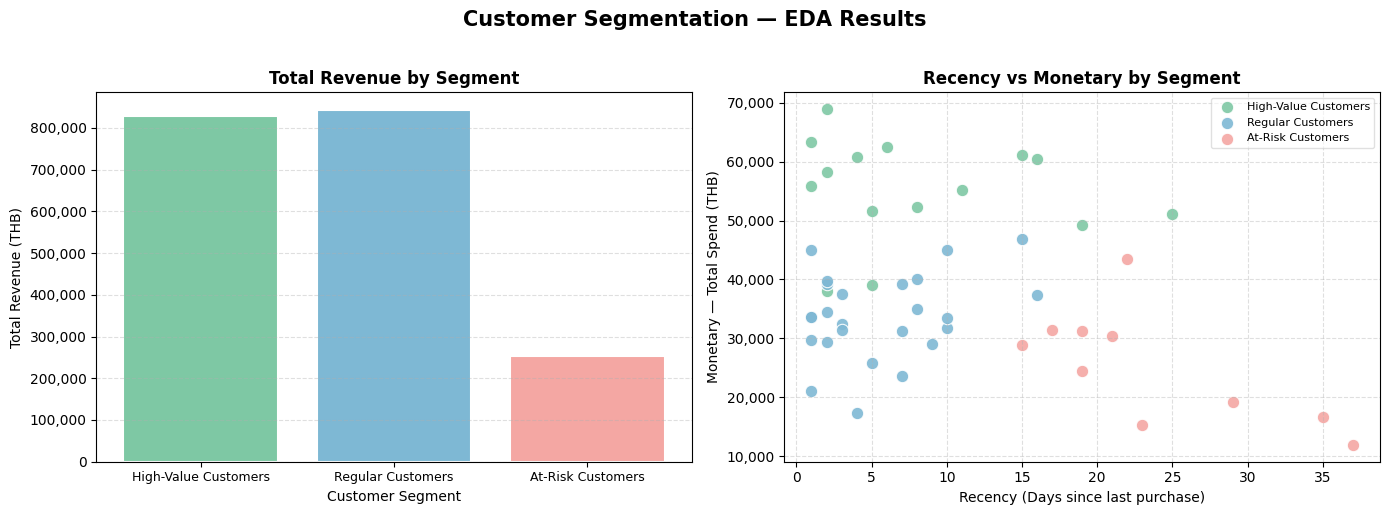

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# กำหนด color palette โทนพาสเทลให้แต่ละกลุ่ม
segment_colors = {
    'High-Value Customers': '#7EC8A4',  # เขียวพาสเทล
    'Regular Customers':    '#7EB8D4',  # ฟ้าพาสเทล
    'At-Risk Customers':    '#F4A7A3'   # แดงพาสเทล
}
order = ['High-Value Customers', 'Regular Customers', 'At-Risk Customers']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Segmentation — EDA Results', fontsize=15, fontweight='bold', y=1.02)

# --- กราฟที่ 1: Total Revenue per Segment ---
# แสดงว่าแต่ละกลุ่มสร้างรายได้รวมต่างกันแค่ไหน
revenue_by_segment = df_rfm.groupby('Segment')['Monetary'].sum().reindex(order)

axes[0].bar(order, revenue_by_segment,
            color=[segment_colors[s] for s in order],
            edgecolor='white', linewidth=1.5)
axes[0].set_title('Total Revenue by Segment', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Customer Segment')
axes[0].set_ylabel('Total Revenue (THB)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
axes[0].tick_params(axis='x', labelsize=9)

# --- กราฟที่ 2: Scatter Plot Recency vs Monetary ---
# โชว์ว่า K-Means แบ่งกลุ่มได้ชัด (ยิ่ง Recency น้อย = ซื้อล่าสุด, Monetary สูง = จ่ายเยอะ)
for segment in order:
    subset = df_rfm[df_rfm['Segment'] == segment]
    axes[1].scatter(subset['Recency'], subset['Monetary'],
                    label=segment,
                    color=segment_colors[segment],
                    edgecolors='white', linewidths=0.8,
                    s=80, alpha=0.9)

axes[1].set_title('Recency vs Monetary by Segment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Recency (Days since last purchase)')
axes[1].set_ylabel('Monetary — Total Spend (THB)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].legend(fontsize=8, framealpha=0.6)
axes[1].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## 🤖 AI Tools ที่ใช้ในการทำงาน

- **การใช้เครื่องมือ AI (Gemini & Claude):** นำมาใช้เป็นผู้ช่วยในการเขียนโค้ด (Coding Assistant) เช่น สคริปต์สร้าง Mock Data และการพล็อตกราฟ เพื่อประหยัดเวลาในส่วนของงานพื้นฐาน รวมถึงช่วยเกลาภาษาในสไลด์ให้กระชับและสื่อสารได้ชัดเจนขึ้น

- **การตรวจสอบผลลัพธ์ (Validation):**
  - ไอเดียการแก้ปัญหา (การเลือกใช้ RFM + K-Means) และการตีความหมายของแต่ละ Segment เป็นการวิเคราะห์และตัดสินใจด้วยตัวเองเพื่อให้ตอบโจทย์ธุรกิจ
  - ตรวจสอบความถูกต้องของโค้ดด้วยการรันและเช็กผลลัพธ์ทีละขั้นตอน เพื่อให้มั่นใจว่าลอจิกการคำนวณและการเตรียมข้อมูลเข้าโมเดลทำได้อย่างถูกต้อง
  - ตรวจสอบความสมเหตุสมผลของ Segment โดยเช็กว่า High-Value Customers มีค่า Monetary เฉลี่ยสูงสุด และ At-Risk Customers มีค่า Recency สูงสุด (นานที่สุดที่ไม่ได้ซื้อ) ซึ่งสอดคล้องกับนิยามของแต่ละกลุ่มตามหลัก RFM ไม่ใช่การตั้งชื่อโดยไม่มีตัวเลขรองรับ
  - ตรวจสอบความสมเหตุสมผลจากกราฟ (Scatter Plot & Bar Chart) ว่ากลุ่มลูกค้าที่โมเดลแบ่งออกมานั้นสะท้อนพฤติกรรมจริง และสามารถนำไปประยุกต์ใช้กับการทำโปรโมชั่นได้จริง